In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.pipeline import Pipeline

---
## <u>Load Dataset</u>

In [2]:
health_data = pd.read_csv("novagen_dataset.csv")

print(health_data.isnull().values.any()) # .isnull() creates a true/false map, .values converts it into an array, .any() returns 
                                         # false if there is no null value in the whole dataset

health_data.info() # 3 datatypes only

# IMP : FOR OUR TARGET VARIABLE, 0 IS HEALTHY AND 1 IN UNHEALTHY
health_data.head()

False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


---
## <u>EDA</u>

- Complete EDA Workflow
    1.  Target Class Balance
    2.  Continuous Feature Distributions: Graphs showing shapes and skewness.
    3.  Categorical Feature Distributions: Graphs showing uniform splits across discrete features.
    4.  Target Separation Check: Comparing continuous features against Target.
    5.  Bivariate Interactions: Scatter plots on top predictors/imp features.
    6.  Linear Relationship Grid: Correlation Heatmap for all the features.

    1. Check if our label class is balanced or is skewed a bit 

    [use histplot for this]

Distribution of labels in % :-
Target
1    52.141586
0    47.858414
Name: proportion, dtype: float64
Key finding : The label column is almost evenly distributed


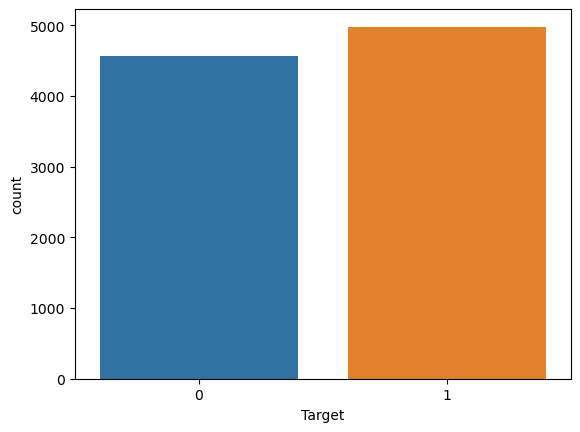

In [3]:
print("Distribution of labels in % :-")
print(f"{health_data["Target"].value_counts(normalize=True) * 100}")

sns.countplot(data = health_data, x = "Target", hue = "Target", legend = False)

print("Key finding : The label column is almost evenly distributed")
# plt.savefig("Hist_plots_label")

    2. Check how the continous features are distributed in our data
    
    [Use hist plots for this]

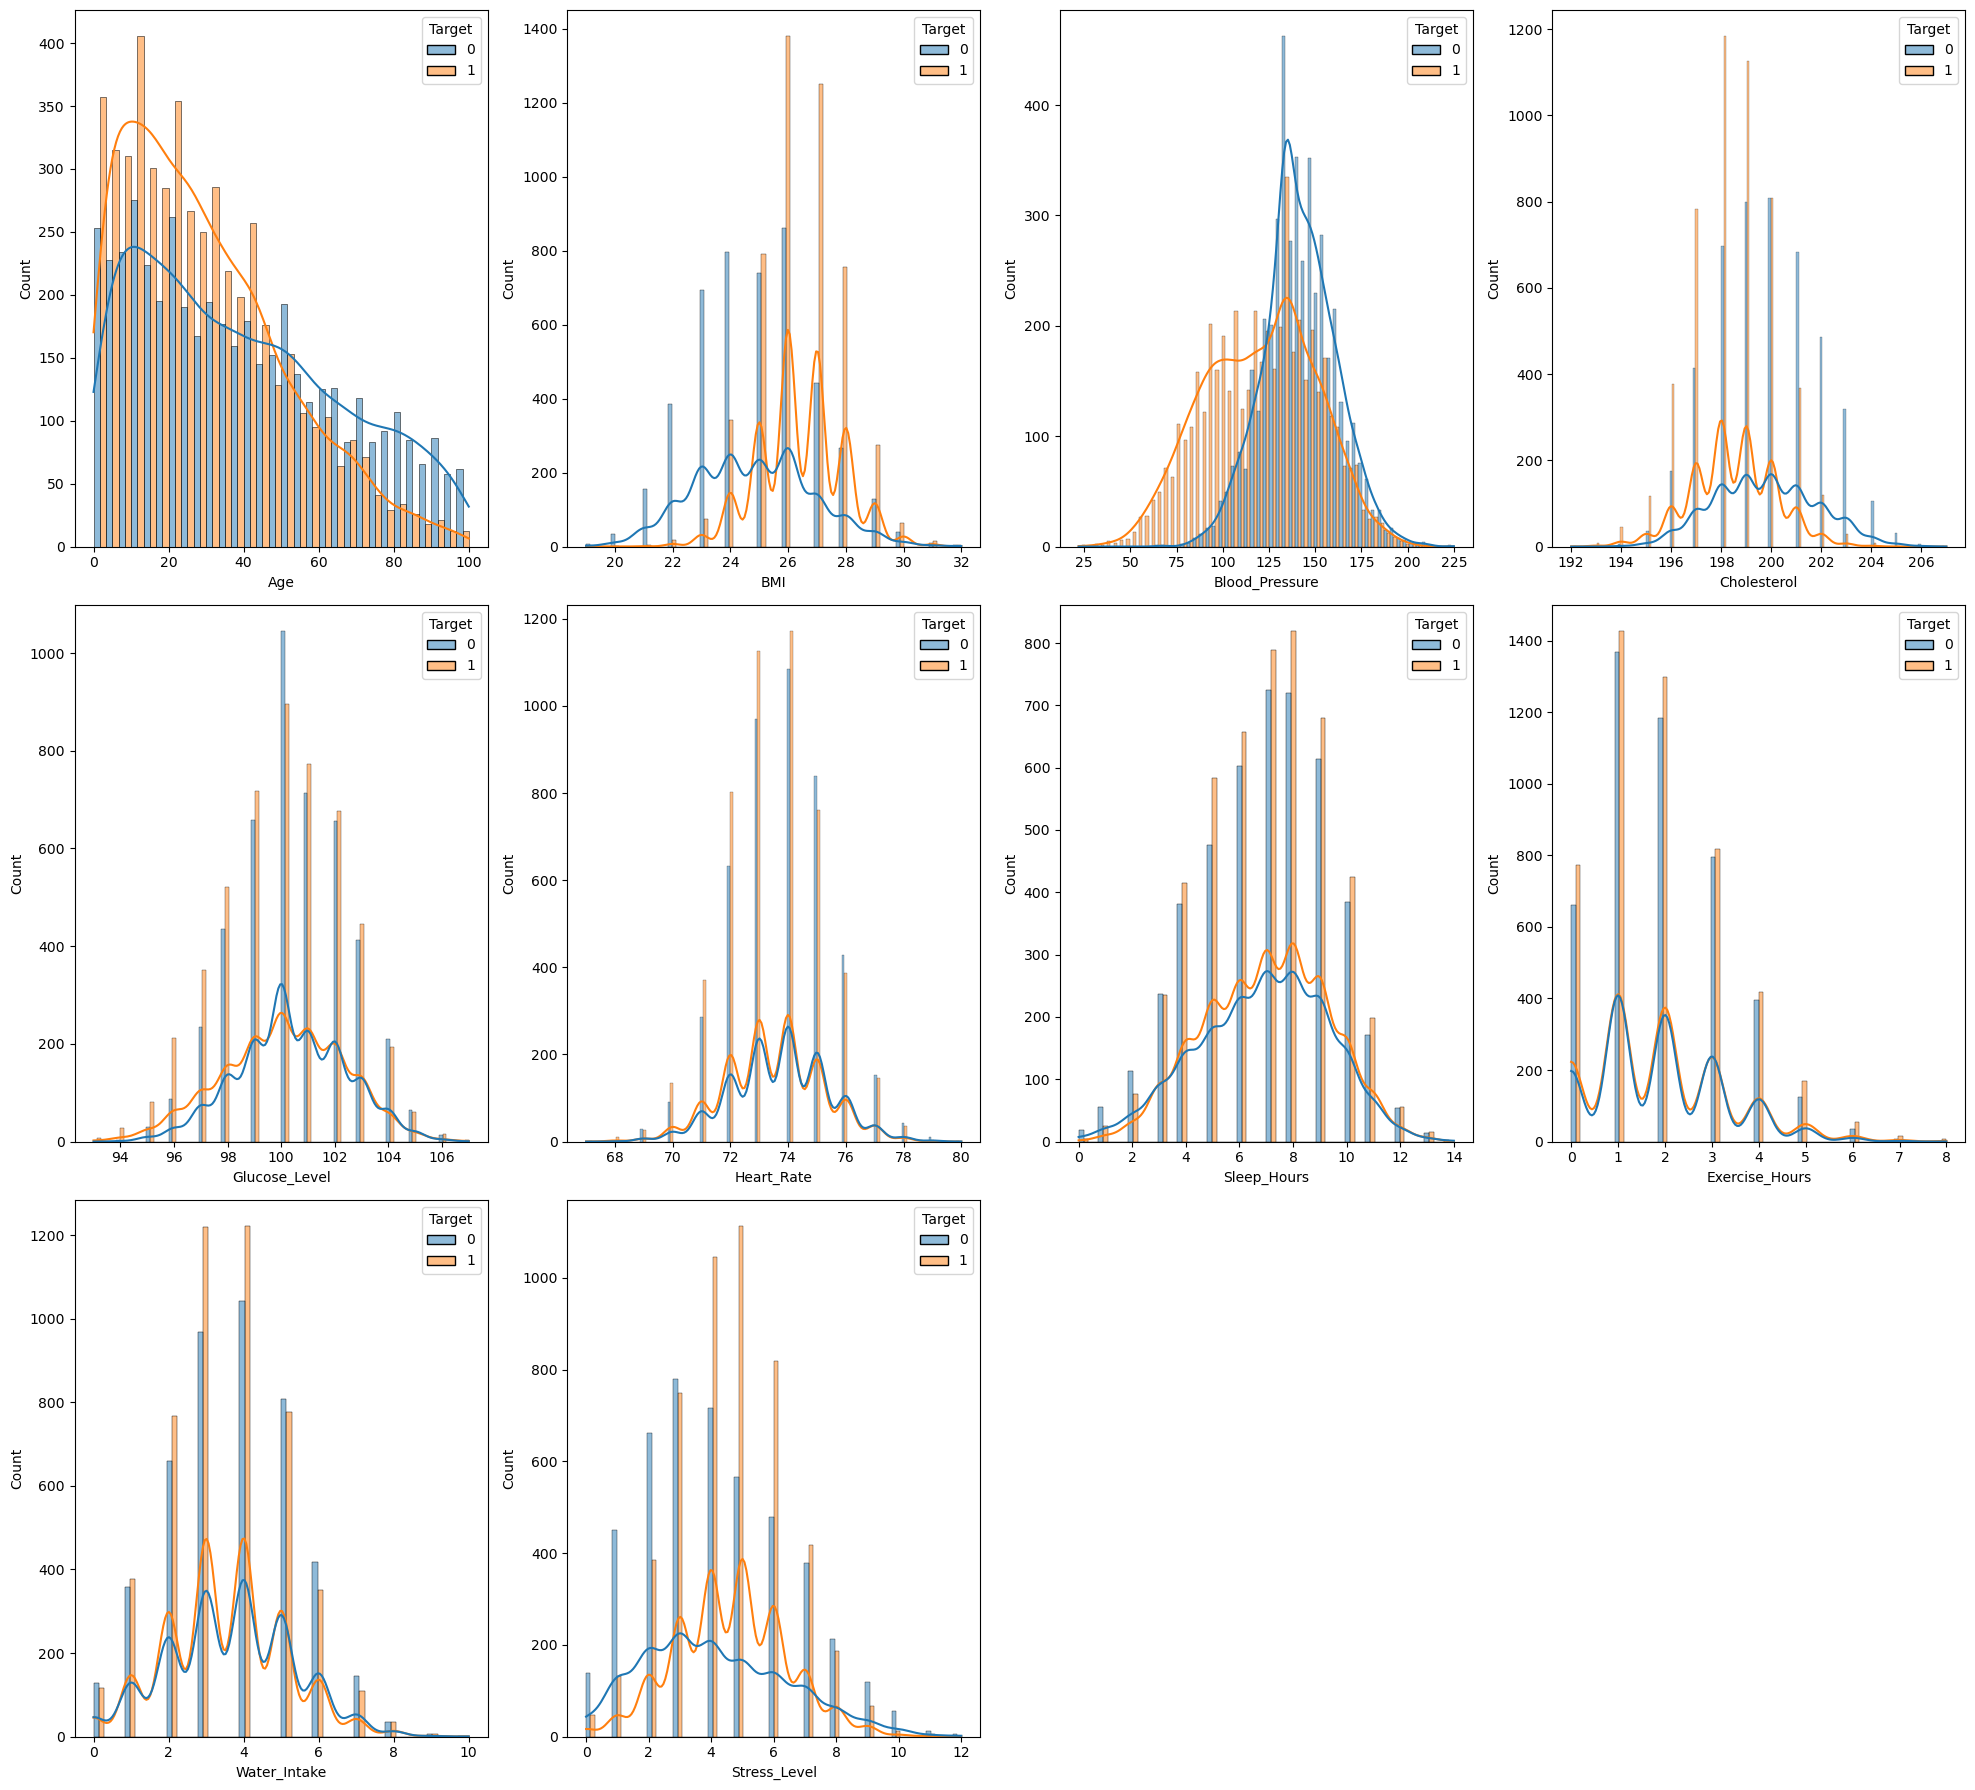

In [4]:
# Set figure size directly inside subplots so the photos are well spaced
fig, axes = plt.subplots(3, 4, figsize=(20, 18))

# 1. Age
sns.histplot(ax=axes[0, 0], data=health_data, x="Age", kde=True, hue = "Target", multiple='dodge')

# 2. BMI
sns.histplot(ax=axes[0, 1], data=health_data, x="BMI", kde=True, hue = "Target", multiple='dodge')

# 3. Blood Pressure
sns.histplot(ax=axes[0, 2], data=health_data, x="Blood_Pressure", kde=True, hue = "Target", multiple='dodge')

# 4. Cholesterol
sns.histplot(ax=axes[0, 3], data=health_data, x="Cholesterol", kde=True, hue = "Target", multiple='dodge')

# 5. Glucose Level
sns.histplot(ax=axes[1, 0], data=health_data, x="Glucose_Level", kde=True, hue = "Target", multiple='dodge')

# 6. Heart Rate
sns.histplot(ax=axes[1, 1], data=health_data, x="Heart_Rate", kde=True, hue = "Target", multiple='dodge')

# 7. Sleep Hours
sns.histplot(ax=axes[1, 2], data=health_data, x="Sleep_Hours", kde=True,  hue = "Target", multiple='dodge')

# 8. Exercise Hours
sns.histplot(ax=axes[1, 3], data=health_data, x="Exercise_Hours", kde=True, hue = "Target", multiple='dodge')

# 9. Water Intake
sns.histplot(ax=axes[2, 0], data=health_data, x="Water_Intake", kde=True, hue = "Target", multiple='dodge')

# 10. Stress Level
sns.histplot(ax=axes[2, 1], data=health_data, x="Stress_Level", kde=True, hue = "Target", multiple='dodge')

# Turn off the 2 empty white boxes in the corner
axes[2, 2].axis('off')
axes[2, 3].axis('off')

plt.tight_layout()
# plt.savefig("Hist_plots_cont_feat")

#### Key Findings :- 
1. Age:
    - Shape: Right-skewed (peaks early, tails off to the right).
    - Hue: Huge separation. Target 1 (orange) is heavily concentrated on the younger side, while Target 0 (blue) skews much older.
2. BMI:
    - Shape: Roughly normal, slightly left-skewed with clear spikes.
    - Hue: Clear separation. Target 1 (orange) is shifted to the right (higher BMI), and Target 0 (blue) is shifted to the left (lower BMI).
3. Blood_Pressure:
    - Shape: Normal/slightly left-skewed.
    - Hue: Strong separation. Target 0 (blue) peaks much further to the right (higher BP), while Target 1 (orange) peaks to the left.
4. Cholesterol:
    - Shape: Normal with sharp, distinct spikes.
    - Hue: Zero separation. The blue and orange lines overlap almost perfectly.
5. Glucose_Level:
    - Shape: Normal with sharp spikes.
    - Hue: Zero separation. Total overlap between both targets.
6. Heart_Rate:
    - Shape: Normal with sharp spikes.
    - Hue: Zero separation. Total overlap.
7. Sleep_Hours:
    - Shape: Normal (bell curve).
    - Hue: Zero separation. Total overlap.
8. Exercise_Hours:
    - Shape: Heavily right-skewed (most people at 1-2 hours).
    - Hue: Zero separation. Total overlap.
9. Water_Intake:
    - Shape: Normal distribution with discrete spikes.
    - Hue: Zero separation. Total overlap.
10. Stress_Level:
    - Shape: Normal, slightly right-skewed.
    - Hue: Slight separation. Target 1 (orange) is slightly more prominent in the higher stress levels compared to Target 0.

    3. Check how the Categorical features is distributed in our data

    [Use Histplots for this]

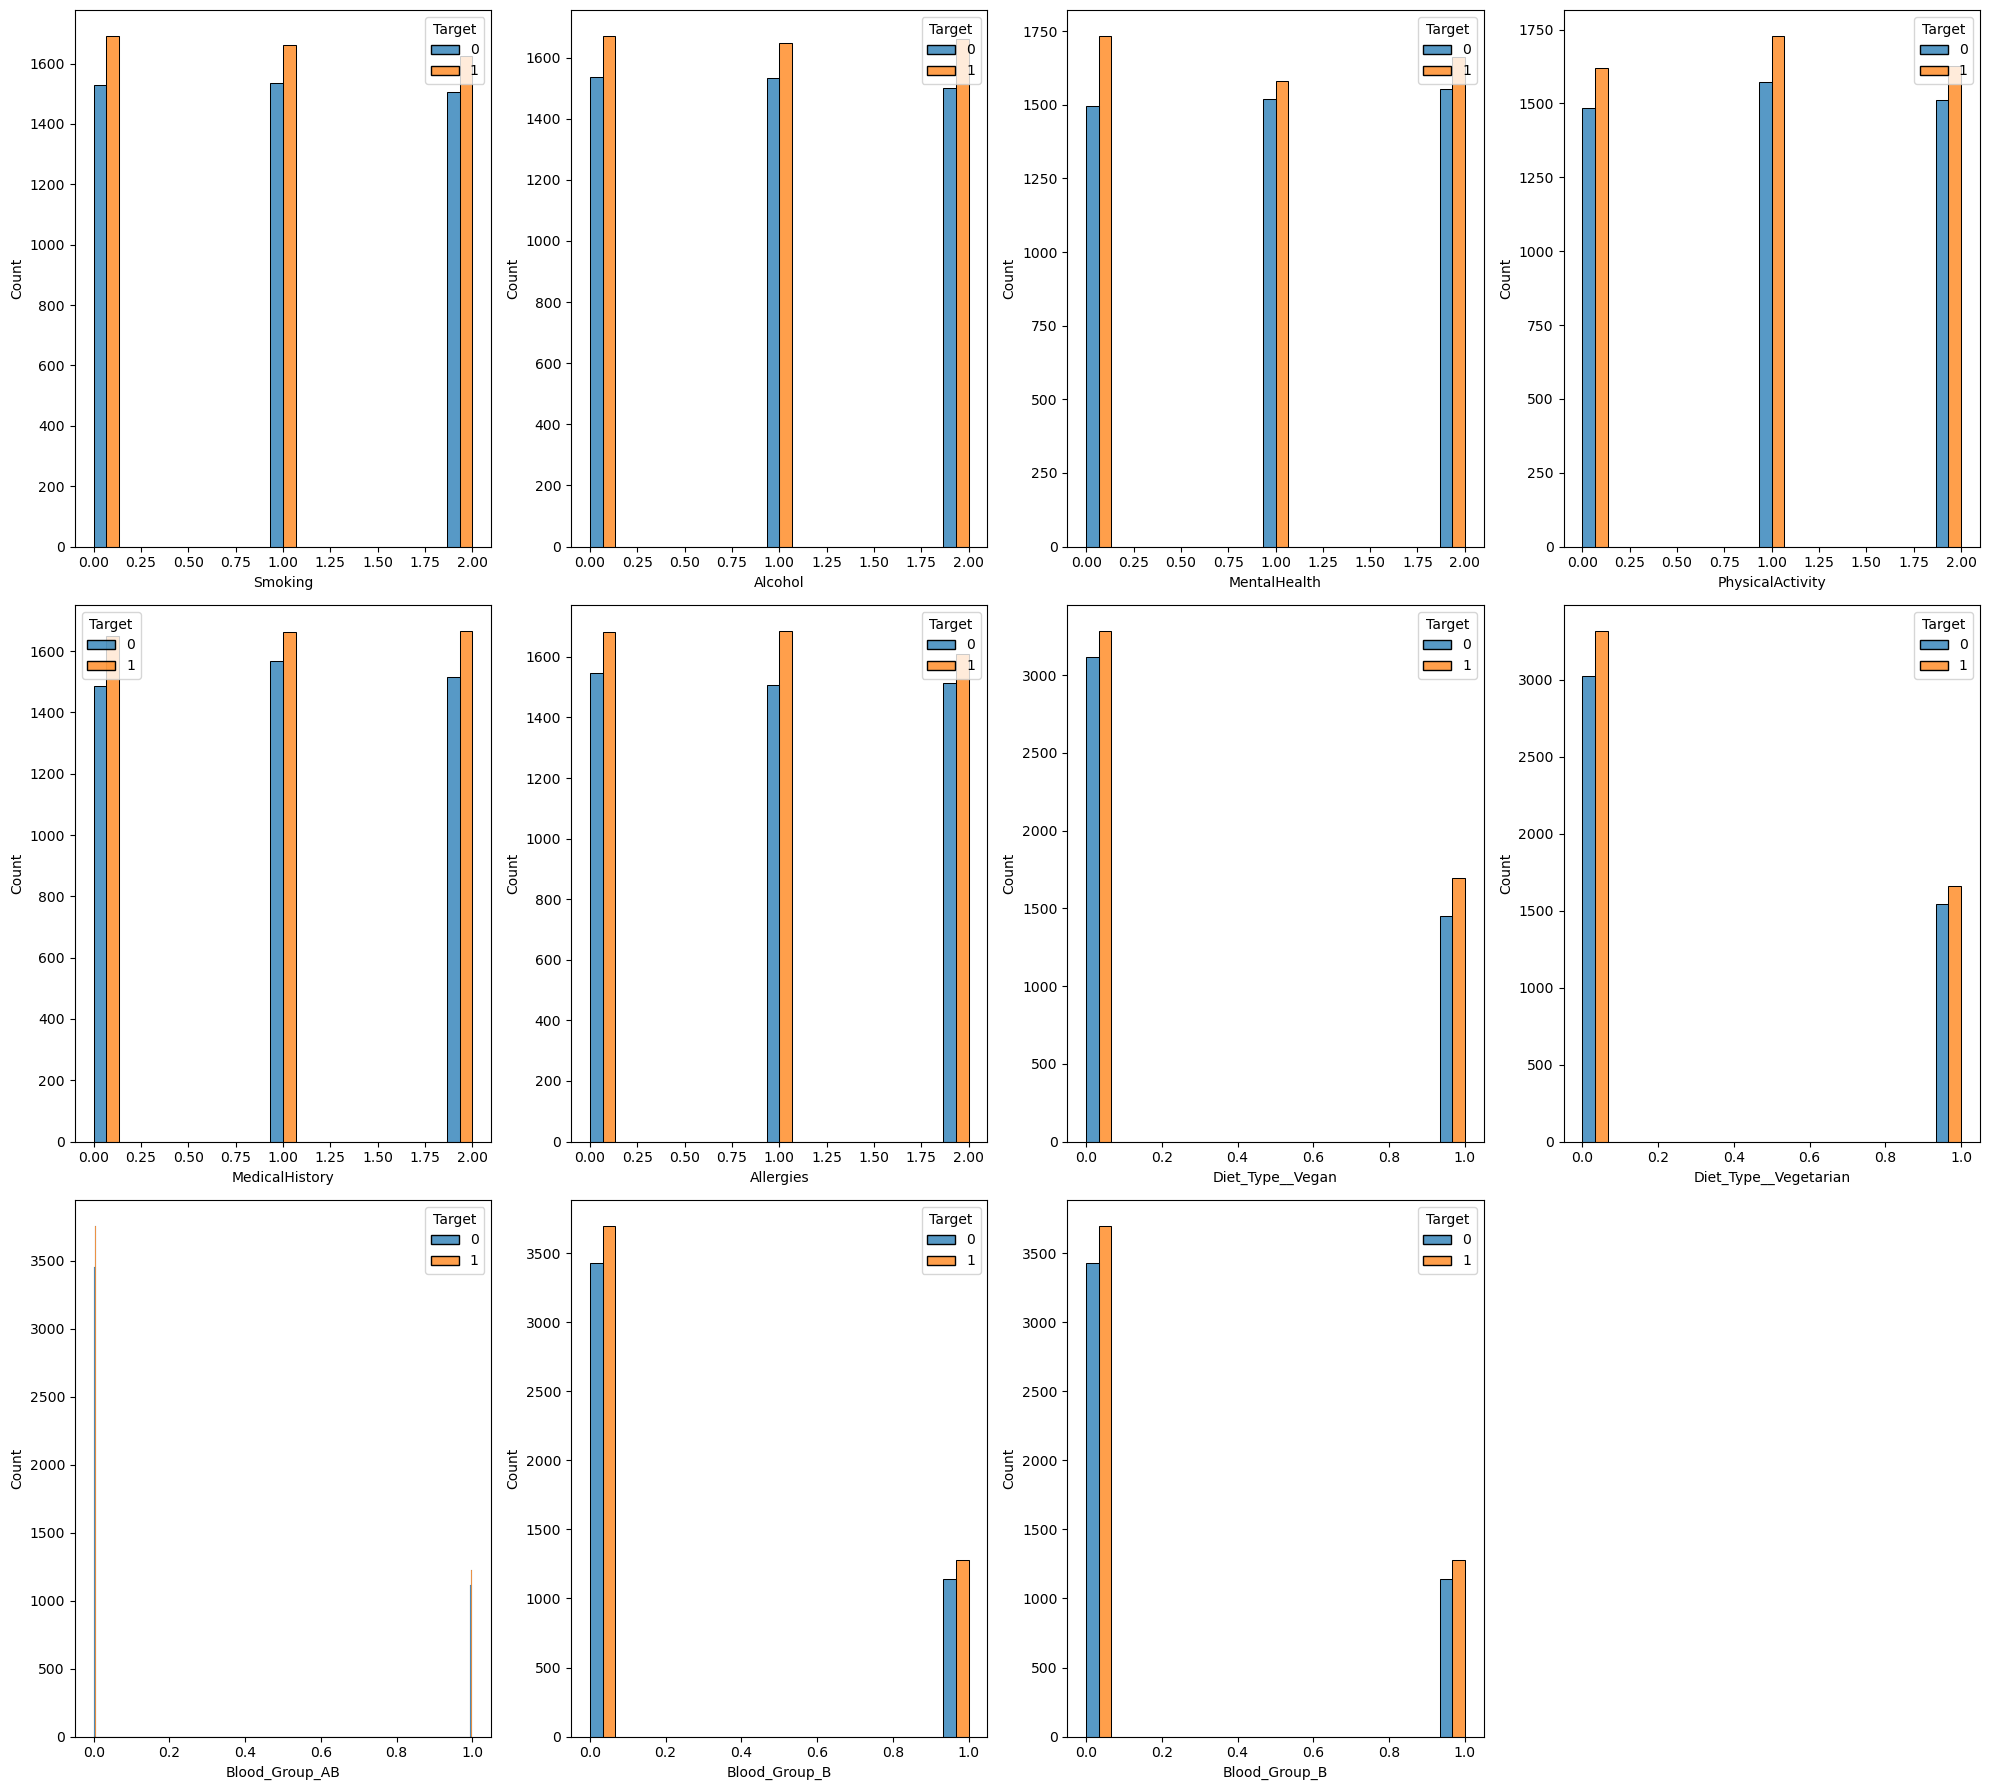

In [5]:
# Set figure size directly inside subplots so the photos are well spaced
fig, axes = plt.subplots(3, 4, figsize=(20, 18))

# 1. Smoking
sns.histplot(ax=axes[0, 0], data=health_data, x="Smoking", hue = "Target", multiple='dodge')

# 2. Alcohol
sns.histplot(ax=axes[0, 1], data=health_data, x="Alcohol", hue = "Target", multiple='dodge')

# 3. MentalHealth
sns.histplot(ax=axes[0, 2], data=health_data, x="MentalHealth", hue = "Target", multiple='dodge')

# 4. PhysicalActivity
sns.histplot(ax=axes[0, 3], data=health_data, x="PhysicalActivity", hue = "Target", multiple='dodge')

# 5. MedicalHistory
sns.histplot(ax=axes[1, 0], data=health_data, x="MedicalHistory", hue = "Target", multiple='dodge')

# 6. Allergies
sns.histplot(ax=axes[1, 1], data=health_data, x="Allergies", hue = "Target", multiple='dodge')

# 7. Diet_Type__Vegan
sns.histplot(ax=axes[1, 2], data=health_data, x="Diet_Type__Vegan", hue = "Target", multiple='dodge')

# 8. Diet_Type__Vegetarian
sns.histplot(ax=axes[1, 3], data=health_data, x="Diet_Type__Vegetarian", hue = "Target", multiple='dodge')

# 9. Blood_Group_AB
sns.histplot(ax=axes[2, 0], data=health_data, x="Blood_Group_AB", hue = "Target", multiple='dodge')

# 10. Blood_Group_B
sns.histplot(ax=axes[2, 1], data=health_data, x="Blood_Group_B", hue = "Target", multiple='dodge')

# 11. Blood_Group_B
sns.histplot(ax=axes[2, 2], data=health_data, x="Blood_Group_B", hue = "Target", multiple='dodge')

# Turn off the empty white box in the corner
axes[2, 3].axis('off')

plt.tight_layout()
# plt.savefig("hist_plots_cat_feat")

#### Key Findings :-

1. Smoking, Alcohol, MentalHealth, PhysicalActivity, MedicalHistory, Allergies:
    - Shape: Multi-class discrete groups (0, 1, 2).
    - Hue: Uniform. In every single category block, Target 1 (orange) is consistently just a tiny bit taller than Target 0 (blue).
2. Diet_Type_Vegan, Diet_Type_Vegetarian:
    - Shape: Binary (0/False is heavily dominant over 1/True).
    - Hue: Uniform. The ratio of orange to blue remains exactly the same whether the diet is true or false.
3. Blood_Group_AB, Blood_Group_B, Blood_Group_O:
    - Shape: Binary (0/False is massively dominant over 1/True).
    - Hue: Uniform. The orange-to-blue ratio remains static across all blood types.

    4. Compare how a continuous feature changes with respect to our target (class 1 and 0) and outlier detection
    
    [Use box plots for this]

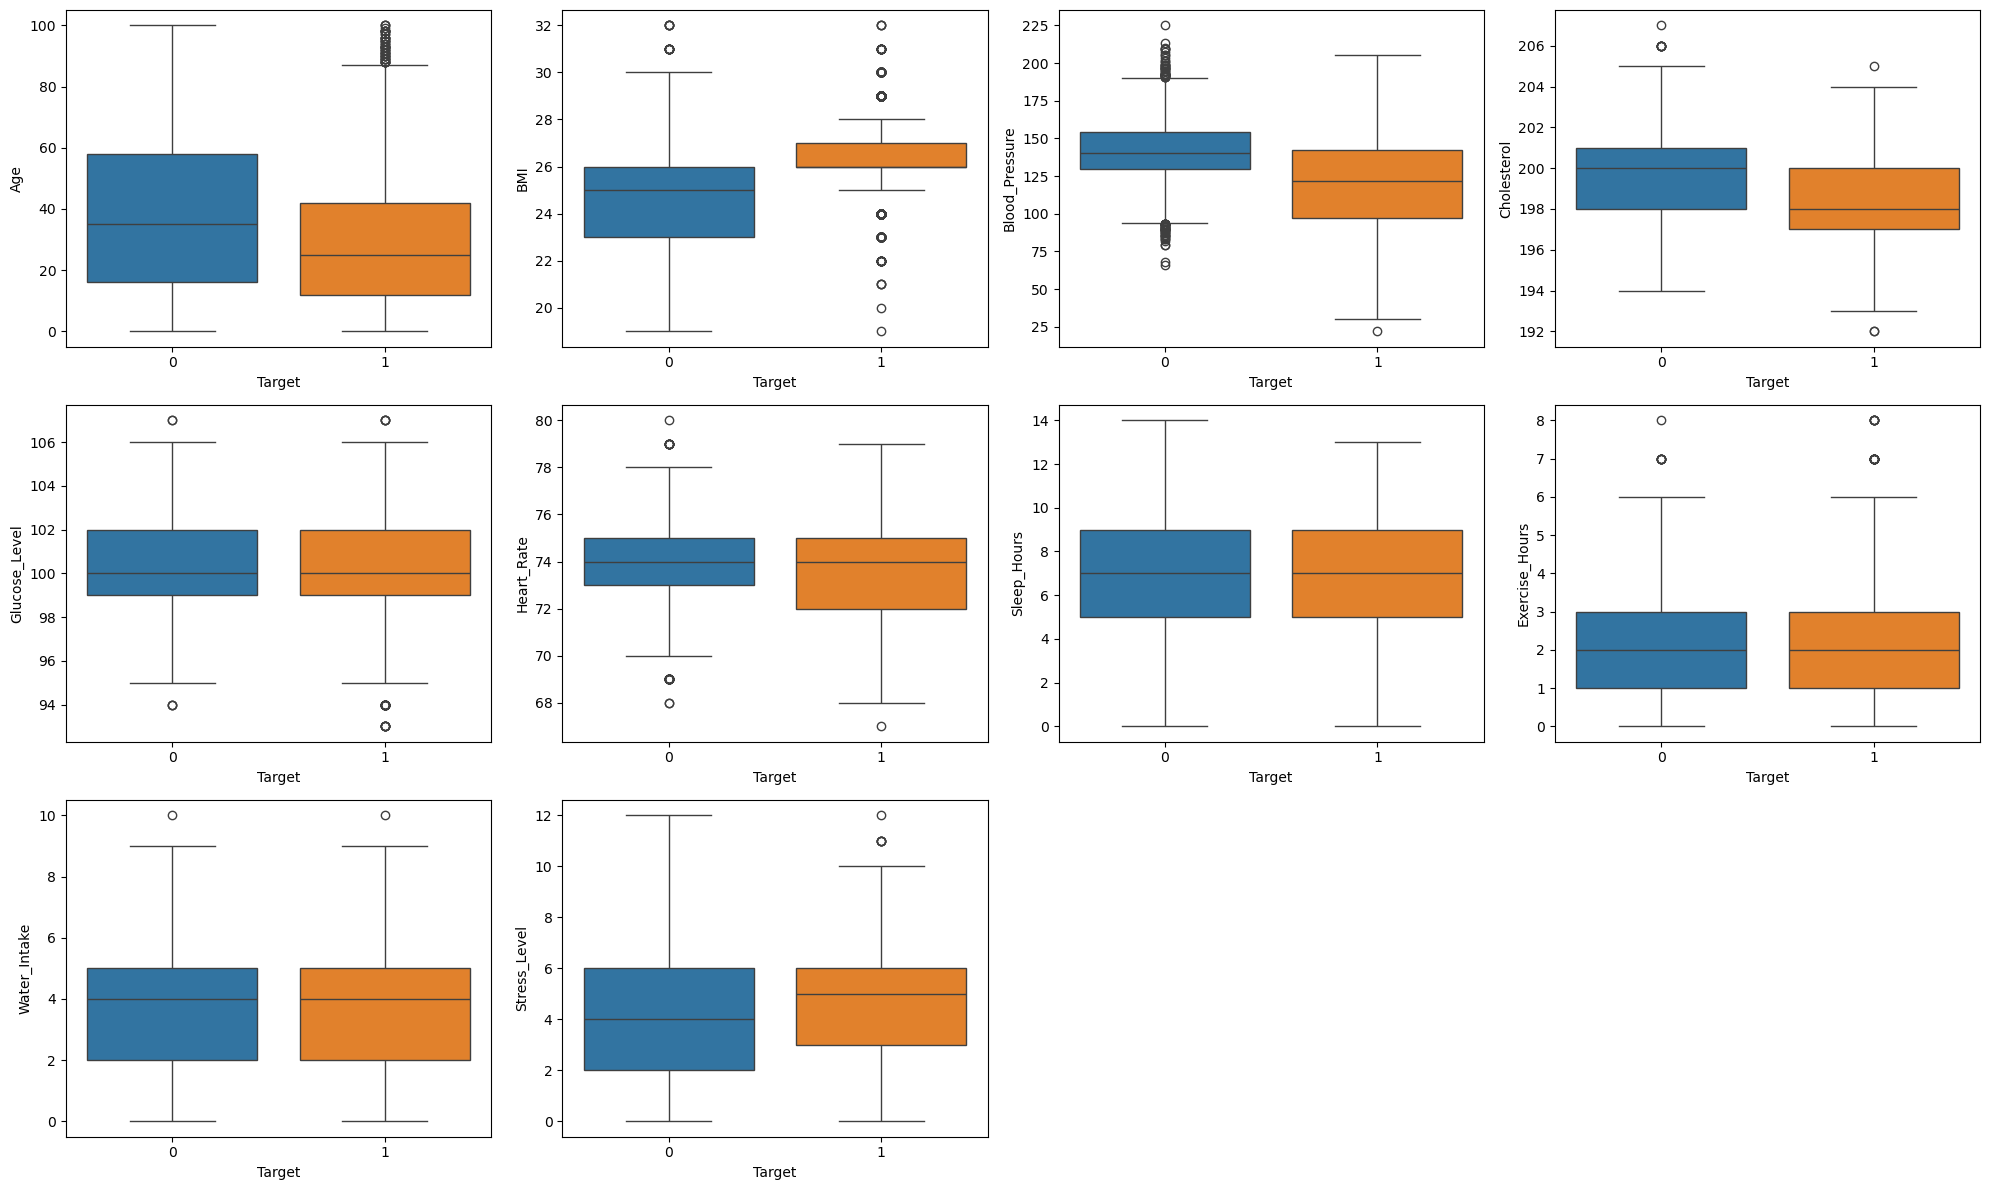

In [6]:
# box plots

# define how many plots in the figure
fig, axes = plt.subplots(3,4,figsize=(20, 12)) # we put figsize in this only so that the images are crisp and well spaced

# 1. Age
sns.boxplot(
    ax = axes[0,0],
    data=health_data, 
    x="Target", 
    y="Age",
    hue = "Target",
    legend = False
)

# 2. BMI
sns.boxplot(
    ax = axes[0,1], 
    data = health_data,
    x = "Target",
    y = "BMI",
    hue = "Target",
    legend = False
)

# 3. Blood_Pressure 
sns.boxplot(
    ax = axes[0,2],
    data = health_data,
    x = "Target",
    y = "Blood_Pressure",
    hue = "Target",
    legend = False
)

# 4. Cholesterol
sns.boxplot(
    ax = axes[0,3],
    data = health_data,
    x = "Target",
    y = "Cholesterol",
    hue = "Target",
    legend = False
)

# 5. Glucose_Level
sns.boxplot(
    ax = axes[1,0],
    data = health_data,
    x = "Target",
    y = "Glucose_Level",
    hue = "Target",
    legend = False
)

# 6. Heart_Rate
sns.boxplot(
    ax = axes[1,1],
    data = health_data,
    x = "Target",
    y = "Heart_Rate",
    hue = "Target",
    legend = False
)

# 7. Sleep_Hours
sns.boxplot(
    ax = axes[1,2],
    data = health_data,
    x = "Target",
    y = "Sleep_Hours",
    hue = "Target",
    legend = False
)

# 8. Exercise_Hours
sns.boxplot(
    ax = axes[1,3],
    data = health_data,
    x = "Target",
    y = "Exercise_Hours",
    hue = "Target",
    legend = False
)

# 9. Water_Intake
sns.boxplot(
    ax = axes[2,0],
    data = health_data,
    x = "Target",
    y = "Water_Intake",
    hue = "Target",
    legend = False
)

# 10. Stress_Level
sns.boxplot(
    ax = axes[2,1],
    data = health_data,
    x = "Target",
    y = "Stress_Level",
    hue = "Target",
    legend = False
)

# Turn off the 2 empty white boxes in the corner
axes[2, 2].axis('off')
axes[2, 3].axis('off')

plt.tight_layout()
# plt.savefig("Box_plots_cont_feat")

## Key Findings :- 
- a feature falls in category (1.), (2.), or (3.) by comparing its median for class 0 and 1, with more separation as more informative


1. Uninformative features (pure noise) :
   - sleep_hours,
   - excersice_hours,
   - water_intake,
   - glucose_level
2. Slightly Informative (almost overlap):
    - heart_rate,
    - stress_level,
    - cholestrol
3. Informative features (important for us) :
    - Age,
    - BMI,
    - Blood_Pressure

    5. Draw scatter plots for the relationship between most imp features
    - In this dataset the most imp features are Age, BMI, and Blood_Pressure

    [Use ScatterPlot for this]

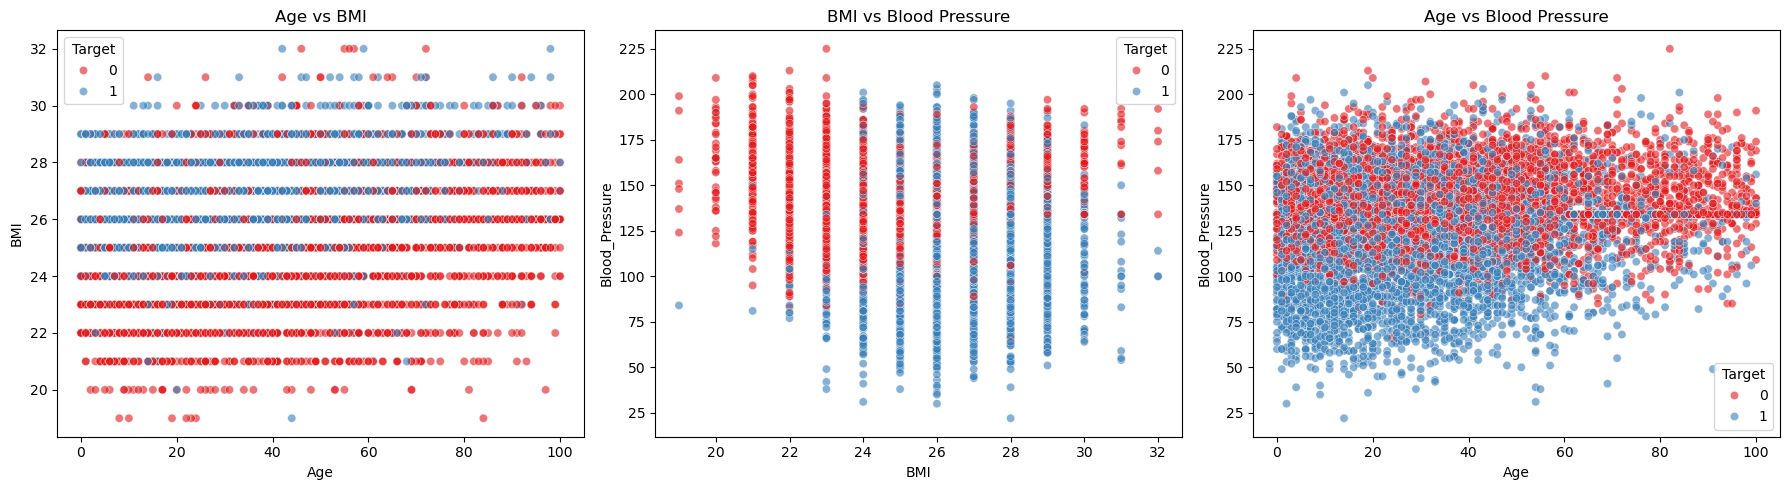

In [7]:
# define figure specifications
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.scatterplot(
    ax = axes[0],   # as the shape of the subplots isnt a 2d array like (3,4) and is a 1d array, we just use [0]
    data = health_data,
    x = "Age",
    y = "BMI",
    hue = "Target",
    alpha=0.6,      # controls the transparency/opacity of the scatter plot dots
    palette='Set1'  # type of default color set for datapoints our graph especially for the hue groups
)
axes[0].set_title('Age vs BMI')

sns.scatterplot(
    ax = axes[1],
    data = health_data,
    x = "BMI",
    y = "Blood_Pressure",
    hue = "Target",
    alpha=0.6,      # controls the transparency/opacity of the scatter plot dots
    palette='Set1'  # type of default color set for datapoints our graph especially for the hue groups
)
axes[1].set_title('BMI vs Blood Pressure')

sns.scatterplot(
    ax = axes[2],
    data = health_data,
    x = "Age",
    y = "Blood_Pressure",
    hue = "Target",
    alpha=0.6,      # controls the transparency/opacity of the scatter plot dots
    palette='Set1'  # type of default color set for datapoints our graph especially for the hue groups
)
axes[2].set_title('Age vs Blood Pressure')

plt.tight_layout()
# plt.savefig("Scatter_Plot_Interact_Feat")

#### Key Findings

1. Higher Blood Pressure values (130 mmHg) are predominantly associated with Target = 0 (Healthy), whereas lower Blood Pressure values (< 130 mmHg) heavily cluster around Target = 1 (Unhealthy).

2. While Target = 0 spans across all age groups at elevated blood pressure levels, younger individuals (40 years) with lower blood pressure form a dense, pure cluster for Target = 1.

3. In the BMI vs Blood Pressure space, Target = 1 forms a strong vertical column concentrated between BMI 25 and 30 at lower blood pressure levels, showing that high BMI combined with low/normal blood pressure strongly drives the risk outcome.

    6. A full blown Correlation map for all the features to see how each one affects the other one

    [Use Heatmap for this]

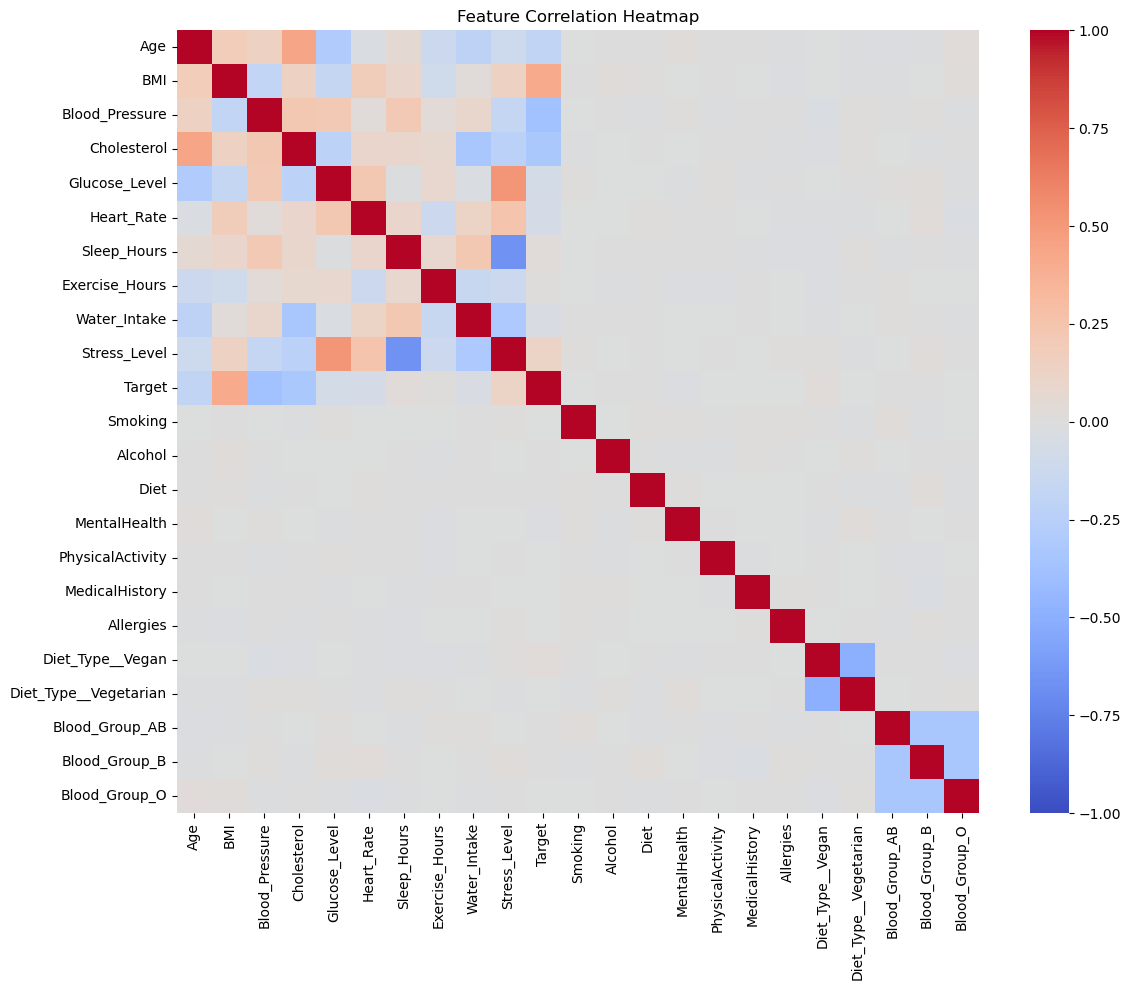

In [8]:
# define figure specifications
plt.figure(figsize=(12, 10))

# get the correlation data from the dataset
corr = health_data.corr()

# Annot=False keeps it clean given the 22 features
# make heatmap
sns.heatmap(
    corr,             # data
    cmap='coolwarm',  # color
    vmin=-1,          # minimum for color scale
    vmax=1            # maximum for color sclae
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()

# plt.savefig("Corr_Heatmap")
# BMI, Blood_Pressure, and Age have the strongest correlations with Target, while the categorical and uninformative continuous features show near-zero correlation values across the board.

---
## <u>Train Test Split</u>

In [9]:
X = health_data.drop(columns = ["Target"])
y = health_data["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

---
## <u>Feature Encoding</u>

In [10]:
# we just need to encode the true false values
# no scaling needed as random forest doesnt need scaling

cat_cols = X_train.select_dtypes(include=["bool"]).columns

preprocessor = ColumnTransformer(
    transformers = [
        ("ord", OrdinalEncoder(), cat_cols)  # ordinal encoder is same as LabelEncoder but just for 2D cols i.e. features (X) 
    ],
    remainder='passthrough' # stops dropping the other columns from X-train except cat_cols
)

preprocessor.set_output(transform = "pandas")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

---
## <u>Create model</u>

- as the assignment guideline says :-
    - classification will support key research decisions, including:
        - Selecting eligible participants for clinical trials and longitudinal studies
        - Stratifying populations for risk-based analysis and outcome comparison


 
This means our main goal is to reduce overfitting and for that we will firs build a baseline random forest model

In [11]:
rfc_model = RandomForestClassifier(
    n_estimators = 301,
    max_depth = 4,
    random_state = 42,
    verbose = 0    
)

rfc_model.fit(X_train, y_train)

,n_estimators,301
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---
## <u>Predict and Evaluate</u>

In [12]:
y_train_pred = rfc_model.predict(X_train)
y_test_pred = rfc_model.predict(X_test)

print("For Random Forest (baseline) :-")
# print("\nBest Parameters : ", rfc_model.best_params_)
print("\nFor training data :-")
print("Accuracy : ", accuracy_score(y_train, y_train_pred))
print("Classification report : \n", classification_report(y_train, y_train_pred))
print("\nFor testing data :-")
print("Accuracy : ", accuracy_score(y_test, y_test_pred))
print("Classification report : \n", classification_report(y_test, y_test_pred))

For Random Forest (baseline) :-

For training data :-
Accuracy :  0.8357271095152603
Classification report : 
               precision    recall  f1-score   support

           0       0.88      0.76      0.82      3214
           1       0.80      0.91      0.85      3470

    accuracy                           0.84      6684
   macro avg       0.84      0.83      0.83      6684
weighted avg       0.84      0.84      0.83      6684


For testing data :-
Accuracy :  0.8467713787085515
Classification report : 
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1356
           1       0.82      0.91      0.86      1509

    accuracy                           0.85      2865
   macro avg       0.85      0.84      0.84      2865
weighted avg       0.85      0.85      0.85      2865



#### Key Findings :-

1. Zero Overfitting (Training Accuracy: 83.57%, Testing Accuracy: 84.68%)
2. Class 1 (Unhealthy / High Risk): Has high Recall (0.91). This is ideal for medical/clinical trial screening where catching high-risk cases is priority #1.
3. Class 0 (Healthy / Low Risk): Has higher Precision (0.89).

- But we need to turn up the scores a bit and for that we will switch to boosing algo
- We will use CATBOOST because :-

  1. CatBoost uses Symmetric/Oblivious Trees i.e Every node at the same level of the tree uses the exact same splitting condition which will reduce overfitting massively
  2. GBM is very slow and sensitive to hyperparameter tuning
  3. LightGBM is better for large datasets (100k rows)
  4. AdaBoost is good but penalises outliers too heavily and we have many outliers in features like blood_pressure etc so that will make it overfit
  5. Biggest reason is that although we encoded the categorical features to (0,1,2), other boosters will treat them as continuous numerical values which will interaction between features, but on the other hand cat_features in CATBOOST uses Ordered Target Statistics which calculates dynamic, high-dimensional target encodings during the training process across feature combinations (e.g., combining Smoking + Diet when it can)

---
## <u>Catboost Classifier (Hyperparameter tuning)</u>

In [21]:
# Although the int columns in our data is not a categorical column but they are alse encoded into 1,2,3,4,5 etc so we can pass them
# into cat features

# 1. Define categorical columns cleanly as a 1D Python list of names
cat_cols = X_train.select_dtypes(include=["int", "bool"]).columns.tolist()

# 2. Build Pipeline (Clean CatBoost instantiation)
steps = [("cbc", CatBoostClassifier(random_state=42, verbose=0))]
pipeline = Pipeline(steps)

# 3. Clean Hyperparameter Grid
param_grid = {
    "cbc__iterations": [100, 300, 500],
    "cbc__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "cbc__l2_leaf_reg": [1, 3, 5, 7],
    "cbc__subsample": [0.6, 0.8, 1.0],
    "cbc__max_depth": [4, 6, 8]  
}

# 4. RandomizedSearchCV Setup
cbc_model_cv = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=25,         # 20 random combinations for quick cross validation
    cv=5,
    verbose=1,         # Prints real-time progress logs while the code executes
    random_state=42,
    scoring="recall",  # Maximizing Class 1 recall as per requirements
    n_jobs=-1
)

# 5. Fit directly, passing cat_features cleanly to the fit step!
cbc_model_cv.fit(X_train, y_train, cbc__cat_features=cat_cols)

# 6. Predict
y_train_pred = cbc_model_cv.predict(X_train)
y_test_pred = cbc_model_cv.predict(X_test)

# 7. Results
print("for Catboost Classifier:-")
print("\nBest parameters : ", cbc_model_cv.best_params_)
print("\nFor training data :-")
print("Train Accuracy : ", accuracy_score(y_train, y_train_pred))
print("Classification Report :\n", classification_report(y_train, y_train_pred))
print("\nFor testing data :-")
print("Test Accuracy : ", accuracy_score(y_test, y_test_pred))
print("Classification Report :\n", classification_report(y_test, y_test_pred))

# 8. make a dictionary to know which category contributed the most and so on to our model scores i.e. to know their importance
feature_importances = cbc_model_cv.best_estimator_['cbc'].get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df

Fitting 5 folds for each of 25 candidates, totalling 125 fits
for Catboost Classifier:-

Best parameters :  {'cbc__subsample': 0.8, 'cbc__max_depth': 6, 'cbc__learning_rate': 0.1, 'cbc__l2_leaf_reg': 5, 'cbc__iterations': 500}

For training data :-
Train Accuracy :  0.9804009575104727
Classification Report :
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3214
           1       0.98      0.98      0.98      3470

    accuracy                           0.98      6684
   macro avg       0.98      0.98      0.98      6684
weighted avg       0.98      0.98      0.98      6684


For testing data :-
Test Accuracy :  0.9535776614310646
Classification Report :
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1356
           1       0.95      0.96      0.96      1509

    accuracy                           0.95      2865
   macro avg       0.95      0.95      0.95      2865
weighted

,Feature,Importance
0,ord__Diet_Type__Vegan,0.475922
1,ord__Diet_Type__Vegetarian,0.287769
2,ord__Blood_Group_AB,0.226083
3,ord__Blood_Group_B,0.263605
4,ord__Blood_Group_O,0.149840
5,remainder__Age,4.615555
6,remainder__BMI,19.143016
7,remainder__Blood_Pressure,16.264214
8,remainder__Cholesterol,10.438057
9,remainder__Glucose_Level,9.344780


---
# <u>Conclusion</u>

- While the Random Forest baseline model had zero variance gap ($83.58\%$ train vs. $84.68\%$ test), it suffered from high bias (underfitting). 
- CatBoost successfully captured higherer order feature interactions, boosting overall test accuracy to $95.36\%$ with a minimal, acceptable variance gap of $2.68\%$ ($98.04\%$ train). 
- Furthermore, We can clearly see that BMI, Blood_Pressure and SleepHours are the 3 most important features for our model



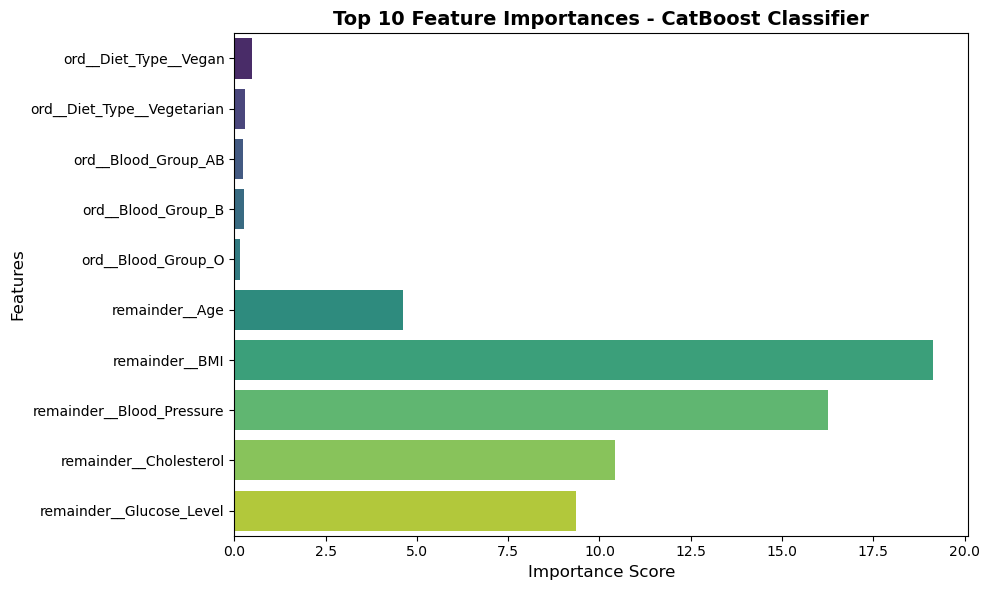

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plotting the top 10 most important features
sns.barplot(
    data=importance_df.head(10), 
    x='Importance', 
    y='Feature', 
    palette='viridis',
    hue = 'Feature'
)

plt.title('Top 10 Feature Importances - CatBoost Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()